# Cálculo de magnitud de momento $M_w$

Este notebook estima la magnitud de momento $M_w$ a partir de los sismogramas de desplazamiento contenidos en la carpeta `DatosInt`. Los registros corresponden a las tres componentes de cinco estaciones:

- MNMCX
- PATA
- PSGCX
- UNAP
- PB07

A diferencia de la magnitud local $M_L$, cuyo cálculo utiliza la amplitud máxima de un sismograma Wood--Anderson, la magnitud de momento se estima a partir del **plateau de baja frecuencia** del espectro de desplazamiento de la onda S.

Para cada estación se selecciona una ventana temporal que contenga únicamente la onda S y su coda temprana. Luego se calcula el espectro de amplitud de las componentes E, N y Z, y se obtiene el valor del plateau:

$$
\Omega_E, \qquad \Omega_N, \qquad \Omega_Z.
$$

El momento sísmico se calcula mediante:

$$
M_0 =
4 \pi \rho \beta^3 R
\frac{V}{\langle R_S \rangle}
\left(
\frac{\Omega_E^2 + \Omega_N^2 + \Omega_Z^2}{3}
\right)^{1/2},
$$

donde:

- $M_0$: momento sísmico en N m;
- $\rho$: densidad cercana a la fuente;
- $\beta$: velocidad de onda S cercana a la fuente;
- $R$: distancia hipocentral;
- $V$: factor de superficie libre;
- $\langle R_S \rangle$: patrón de radiación promedio;
- $\Omega_E$, $\Omega_N$ y $\Omega_Z$: plateaus de baja frecuencia de las tres componentes.

Finalmente, se estima:

$$
M_w =
\frac{2}{3}\log_{10}(M_0) - 6.07.
$$

La magnitud final corresponde al promedio de las magnitudes obtenidas para las cinco estaciones.

In [2]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.facecolor": "white",
    "figure.edgecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "axes.titlecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "grid.color": "lightgray",
    "grid.alpha": 0.45,
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white",
    "savefig.transparent": False,
    "font.size": 11
})

RUTA_DATOS_INT = Path(
    "/home/keneth/Documents/Academic_Projects/AGCID2026_DIS_UChile/Week3/Task_Files/datos_actividad3/DatosInt"
)

DISTANCIAS_EPICENTRALES_KM = {
    "MNMCX": 113.7,
    "PATA": 93.0,
    "PSGCX": 100.7,
    "UNAP": 84.8,
    "PB07": 185.9,
}

PROFUNDIDAD_KM = 90.0

FACTOR_SUPERFICIE_LIBRE = 2.0
PATRON_RADIACION_PROMEDIO = 0.67

DENSIDAD_G_CM3 = 3.38
VELOCIDAD_S_KM_S = 4.78

DENSIDAD_KG_M3 = DENSIDAD_G_CM3 * 1000.0
VELOCIDAD_S_M_S = VELOCIDAD_S_KM_S * 1000.0

COMPONENTES = ("HHE", "HHN", "HHZ")

if not RUTA_DATOS_INT.exists():
    raise FileNotFoundError(
        f"No existe la carpeta de datos:\n{RUTA_DATOS_INT}"
    )

print(f"Carpeta de datos:\n{RUTA_DATOS_INT}\n")

print("Archivos detectados:")
for archivo in sorted(RUTA_DATOS_INT.glob("*.dat")):
    print(" -", archivo.name)

Carpeta de datos:
/home/keneth/Documents/Academic_Projects/AGCID2026_DIS_UChile/Week3/Task_Files/datos_actividad3/DatosInt

Archivos detectados:
 - CX.MNMCX..HHE.D..deco.int.dat
 - CX.MNMCX..HHN.D..deco.int.dat
 - CX.MNMCX..HHZ.D..deco.int.dat
 - CX.PB07..HHE.D..deco.int.dat
 - CX.PB07..HHN.D..deco.int.dat
 - CX.PB07..HHZ.D..deco.int.dat
 - CX.PSGCX..HHE.D..deco.int.dat
 - CX.PSGCX..HHN.D..deco.int.dat
 - CX.PSGCX..HHZ.D..deco.int.dat
 - IQ.PATA..HHE.D..deco.int.dat
 - IQ.PATA..HHN.D..deco.int.dat
 - IQ.PATA..HHZ.D..deco.int.dat
 - IQ.UNAP..HHE.D..deco.int.dat
 - IQ.UNAP..HHN.D..deco.int.dat
 - IQ.UNAP..HHZ.D..deco.int.dat


## 1. Parámetros físicos y conversiones de unidades

El cálculo requiere utilizar unidades SI para que el momento sísmico quede expresado en N m:

$$
\rho = 3.38~\mathrm{g/cm^3}
= 3380~\mathrm{kg/m^3},
$$

$$
\beta = 4.78~\mathrm{km/s}
= 4780~\mathrm{m/s}.
$$

La distancia utilizada en la ecuación es la distancia hipocentral:

$$
R =
\sqrt{\Delta^2 + h^2},
$$

donde $\Delta$ es la distancia epicentral proporcionada para cada estación y $h=90~\mathrm{km}$ es la profundidad conocida del evento.

Es importante no utilizar directamente la distancia epicentral en la ecuación de $M_0$; primero debe convertirse a distancia hipocentral y luego a metros.

In [3]:
def calcular_distancia_hipocentral(delta_km, profundidad_km=PROFUNDIDAD_KM):
    """
    Calcula la distancia hipocentral R en kilómetros.
    """
    return np.sqrt(delta_km**2 + profundidad_km**2)


tabla_geometria = pd.DataFrame([
    {
        "Estación": estacion,
        "Distancia epicentral Δ [km]": delta_km,
        "Profundidad h [km]": PROFUNDIDAD_KM,
        "Distancia hipocentral R [km]": calcular_distancia_hipocentral(delta_km)
    }
    for estacion, delta_km in DISTANCIAS_EPICENTRALES_KM.items()
]).sort_values("Estación").reset_index(drop=True)

tabla_geometria_mostrar = tabla_geometria.copy()

for columna in [
    "Distancia epicentral Δ [km]",
    "Profundidad h [km]",
    "Distancia hipocentral R [km]"
]:
    tabla_geometria_mostrar[columna] = tabla_geometria_mostrar[columna].round(2)

print("\nParámetros físicos:")
print(f"ρ = {DENSIDAD_KG_M3:.1f} kg/m³")
print(f"β = {VELOCIDAD_S_M_S:.1f} m/s")
print(f"V = {FACTOR_SUPERFICIE_LIBRE:.2f}")
print(f"<Rs> = {PATRON_RADIACION_PROMEDIO:.2f}")
print("Geometría fuente--estación utilizada en el cálculo:")
tabla_geometria_mostrar


Parámetros físicos:
ρ = 3380.0 kg/m³
β = 4780.0 m/s
V = 2.00
<Rs> = 0.67
Geometría fuente--estación utilizada en el cálculo:


,Estación,Distancia epicentral Δ [km],Profundidad h [km],Distancia hipocentral R [km]
0,MNMCX,113.7,90.0,145.01
1,PATA,93.0,90.0,129.42
2,PB07,185.9,90.0,206.54
3,PSGCX,100.7,90.0,135.06
4,UNAP,84.8,90.0,123.66


## 2. Lectura de las tres componentes de desplazamiento

Los archivos de `DatosInt` contienen registros de desplazamiento en metros. Cada estación contiene tres componentes:

- `HHE`: componente este--oeste;
- `HHN`: componente norte--sur;
- `HHZ`: componente vertical.

La función siguiente detecta automáticamente la estación y la componente desde el nombre, siempre que incluya los códigos `HHE`, `HHN` o `HHZ`.

In [4]:
def interpretar_nombre_archivo_int(nombre):
    """
    Identifica red, estación y componente en nombres como:
    CX.MNMCX..HHE.D..deco.int.dat
    IQ.PATA..HHN.D..deco.int.dat
    CX.PB07..HHZ.D..deco.int.dat
    """
    partes = nombre.split(".")

    if len(partes) < 4:
        raise ValueError(f"Formato no reconocido: {nombre}")

    red = partes[0]
    estacion = partes[1]

    componente = next(
        (parte for parte in partes if parte in COMPONENTES),
        None
    )

    if componente is None:
        raise ValueError(
            f"No se encontró HHE, HHN o HHZ en el archivo: {nombre}"
        )

    return red, estacion, componente


def leer_traza_int(ruta):
    """
    Lee un archivo de desplazamiento con dos columnas:
    tiempo [s] y amplitud [m].
    """
    df = pd.read_csv(
        ruta,
        sep=r"\s+",
        names=["t_s", "desplazamiento_m"],
        engine="python"
    )

    df = (
        df
        .dropna()
        .sort_values("t_s")
        .reset_index(drop=True)
    )

    return df


def cargar_trazas_int(carpeta, estaciones_validas):
    """
    Carga las trazas de desplazamiento de las estaciones requeridas.
    """
    trazas = {}
    archivos_no_usados = []

    for ruta in sorted(Path(carpeta).glob("*.dat")):
        try:
            red, estacion, componente = interpretar_nombre_archivo_int(
                ruta.name
            )
        except ValueError:
            archivos_no_usados.append(ruta.name)
            continue

        if estacion not in estaciones_validas:
            archivos_no_usados.append(ruta.name)
            continue

        trazas[(estacion, componente)] = {
            "red": red,
            "archivo": ruta.name,
            "datos": leer_traza_int(ruta)
        }

    return trazas, archivos_no_usados


trazas_int, archivos_no_usados = cargar_trazas_int(
    carpeta=RUTA_DATOS_INT,
    estaciones_validas=DISTANCIAS_EPICENTRALES_KM
)

if not trazas_int:
    raise RuntimeError(
        "No se cargaron trazas. Revise la ruta y los nombres de archivo."
    )

resumen_archivos_int = pd.DataFrame([
    {
        "Estación": estacion,
        "Componente": componente,
        "Red": info["red"],
        "Archivo": info["archivo"],
        "Número de muestras": len(info["datos"]),
        "Duración [s]": (
            info["datos"]["t_s"].iloc[-1]
            - info["datos"]["t_s"].iloc[0]
        )
    }
    for (estacion, componente), info in trazas_int.items()
]).sort_values(
    ["Estación", "Componente"]
).reset_index(drop=True)

resumen_archivos_int_mostrar = resumen_archivos_int.copy()
resumen_archivos_int_mostrar["Duración [s]"] = (
    resumen_archivos_int_mostrar["Duración [s]"].round(2)
)


print("\nVerificación de componentes disponibles por estación:")

for estacion in DISTANCIAS_EPICENTRALES_KM:
    disponibles = sorted(
        componente
        for est, componente in trazas_int
        if est == estacion
    )
    print(f"{estacion}: {disponibles}")

if archivos_no_usados:
    print("\nArchivos no utilizados:")
    for archivo in archivos_no_usados:
        print(" -", archivo)

print("Resumen de trazas cargadas:")
resumen_archivos_int_mostrar


Verificación de componentes disponibles por estación:
MNMCX: ['HHE', 'HHN', 'HHZ']
PATA: ['HHE', 'HHN', 'HHZ']
PSGCX: ['HHE', 'HHN', 'HHZ']
UNAP: ['HHE', 'HHN', 'HHZ']
PB07: ['HHE', 'HHN', 'HHZ']
Resumen de trazas cargadas:


,Estación,Componente,Red,Archivo,Número de muestras,Duración [s]
0,MNMCX,HHE,CX,CX.MNMCX..HHE.D..deco.int.dat,17001,170.0
1,MNMCX,HHN,CX,CX.MNMCX..HHN.D..deco.int.dat,17001,170.0
2,MNMCX,HHZ,CX,CX.MNMCX..HHZ.D..deco.int.dat,17001,170.0
3,PATA,HHE,IQ,IQ.PATA..HHE.D..deco.int.dat,17001,170.0
4,PATA,HHN,IQ,IQ.PATA..HHN.D..deco.int.dat,17001,170.0
5,PATA,HHZ,IQ,IQ.PATA..HHZ.D..deco.int.dat,17001,170.0
6,PB07,HHE,CX,CX.PB07..HHE.D..deco.int.dat,17001,170.0
7,PB07,HHN,CX,CX.PB07..HHN.D..deco.int.dat,17001,170.0
8,PB07,HHZ,CX,CX.PB07..HHZ.D..deco.int.dat,17001,170.0
9,PSGCX,HHE,CX,CX.PSGCX..HHE.D..deco.int.dat,17001,170.0


## 3. Visualización de todas las trazas de desplazamiento

La siguiente celda grafica las tres componentes de cada estación. El objetivo es identificar la llegada de la onda S y definir una ventana temporal que contenga la señal S y parte de su coda temprana.

Para seleccionar la onda S, se consideran los siguientes criterios:

1. La onda S suele presentar un incremento claro de amplitud después de la onda P.
2. Normalmente es más visible en las componentes horizontales E y N.
3. La ventana debe comenzar poco antes de la llegada S.
4. La ventana debe terminar antes de que la señal quede dominada por ruido.
5. Para una misma estación se debe usar la misma ventana temporal en HHE, HHN y HHZ.

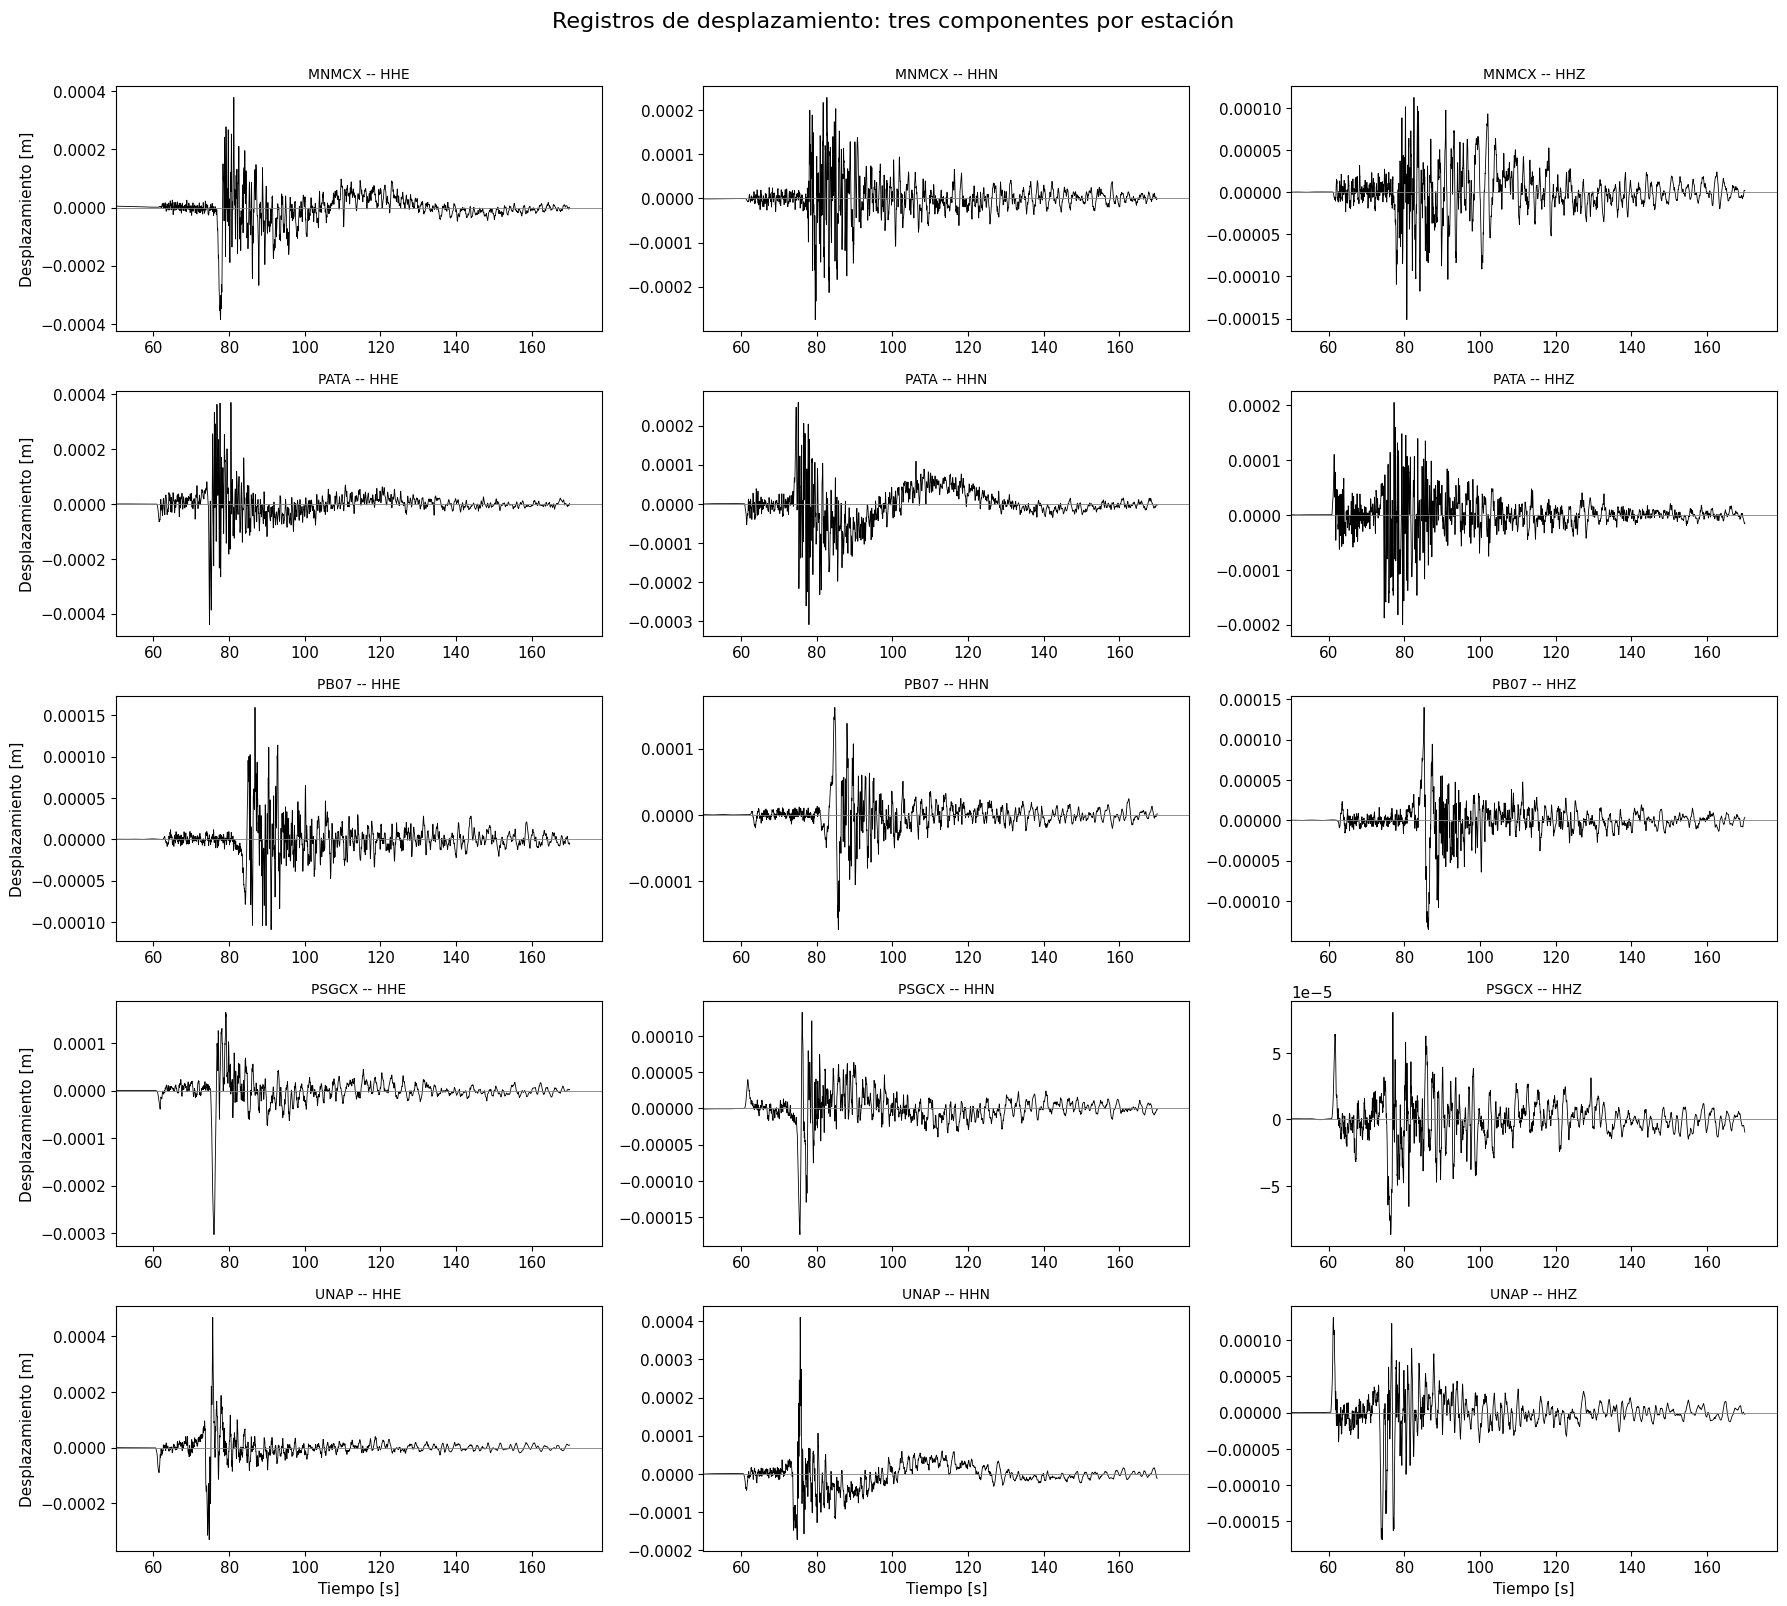

In [5]:
estaciones_ordenadas = sorted(DISTANCIAS_EPICENTRALES_KM)

fig, axes = plt.subplots(
    len(estaciones_ordenadas),
    3,
    figsize=(18, 3.2 * len(estaciones_ordenadas)),
    sharex=False
)

for fila, estacion in enumerate(estaciones_ordenadas):
    for columna, componente in enumerate(COMPONENTES):
        ax = axes[fila, columna]

        clave = (estacion, componente)

        if clave not in trazas_int:
            ax.text(
                0.5,
                0.5,
                f"Sin datos\n{estacion} -- {componente}",
                ha="center",
                va="center"
            )
            ax.set_axis_off()
            continue

        datos = trazas_int[clave]["datos"]

        ax.plot(
            datos["t_s"],
            datos["desplazamiento_m"],
            color="black",
            lw=0.6
        )

        ax.axhline(0, color="gray", lw=0.6)

        ax.set_title(
            f"{estacion} -- {componente}",
            fontsize=10
        )
        ax.set_xlim(left=50)

        if columna == 0:
            ax.set_ylabel("Desplazamiento [m]")

        if fila == len(estaciones_ordenadas) - 1:
            ax.set_xlabel("Tiempo [s]")

fig.suptitle(
    "Registros de desplazamiento: tres componentes por estación",
    y=1.002,
    fontsize=16
)

plt.tight_layout()
plt.savefig(
    "/home/keneth/Documents/Academic_Projects/AGCID2026_DIS_UChile/Week3/Figures/Registros_desplazamiento_tres_componentes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 4. Definición manual de ventanas de onda S

Después de revisar las figuras anteriores, se determinaron los siguientes valores de inicio y final de la ventana de onda S:
1. MNMCX: t_ini_s = 70.0 s, t_fin_s = 100.0 s
2. PATA: t_ini_s = 70.0 s, t_fin_s = 90.0 s
3. PB07: t_ini_s = 75.0 s, t_fin_s = 100.0 s
4. PSGCX: t_ini_s = 70.0 s, t_fin_s = 90.0 s
5. UNAP: t_ini_s = 70.0 s, t_fin_s = 85.0 s

Los valores de frecuencia mínima y máxima del plateau se definiron inicialmente usando la definición:

$$ \delta f = 1 / (t_{fin} - t_{ini}) $$

Posteriormente, se usaron las figuras de más adelante para representar cada banda de frecuencias de la forma más adecuada, por inspección visual:

In [36]:
seleccion_s = {
    "MNMCX": {
        "t_inicio_s": 75.0,
        "t_final_s": 100.0,
        "fmin_plateau_hz": 0.18,
        "fmax_plateau_hz": 1
    },
    "PATA": {
        "t_inicio_s": 70.0,
        "t_final_s": 90.0,
        "fmin_plateau_hz": 0.18,
        "fmax_plateau_hz": 3
    },
    "PSGCX": {
        "t_inicio_s": 70.0,
        "t_final_s": 90.0,
        "fmin_plateau_hz": 0.18,
        "fmax_plateau_hz": 0.8
    },
    "UNAP": {
        "t_inicio_s": 70.0,
        "t_final_s": 85.0,
        "fmin_plateau_hz": 0.22,
        "fmax_plateau_hz": 1
    },
    "PB07": {
        "t_inicio_s": 80.0,
        "t_final_s": 100.0,
        "fmin_plateau_hz": 0.18,
        "fmax_plateau_hz": 1
    }
}

pd.DataFrame(seleccion_s).T

,t_inicio_s,t_final_s,fmin_plateau_hz,fmax_plateau_hz
MNMCX,75.0,100.0,0.18,1.0
PATA,70.0,90.0,0.18,3.0
PSGCX,70.0,90.0,0.18,0.8
UNAP,70.0,85.0,0.22,1.0
PB07,80.0,100.0,0.18,1.0


## 5. Inspección detallada de una estación

Esta celda muestra las tres componentes de una estación y resalta la ventana S seleccionada. La idea con ella es ajustar los valores de la celda anterior hasta que la franja incluya correctamente la onda S en las tres componentes.

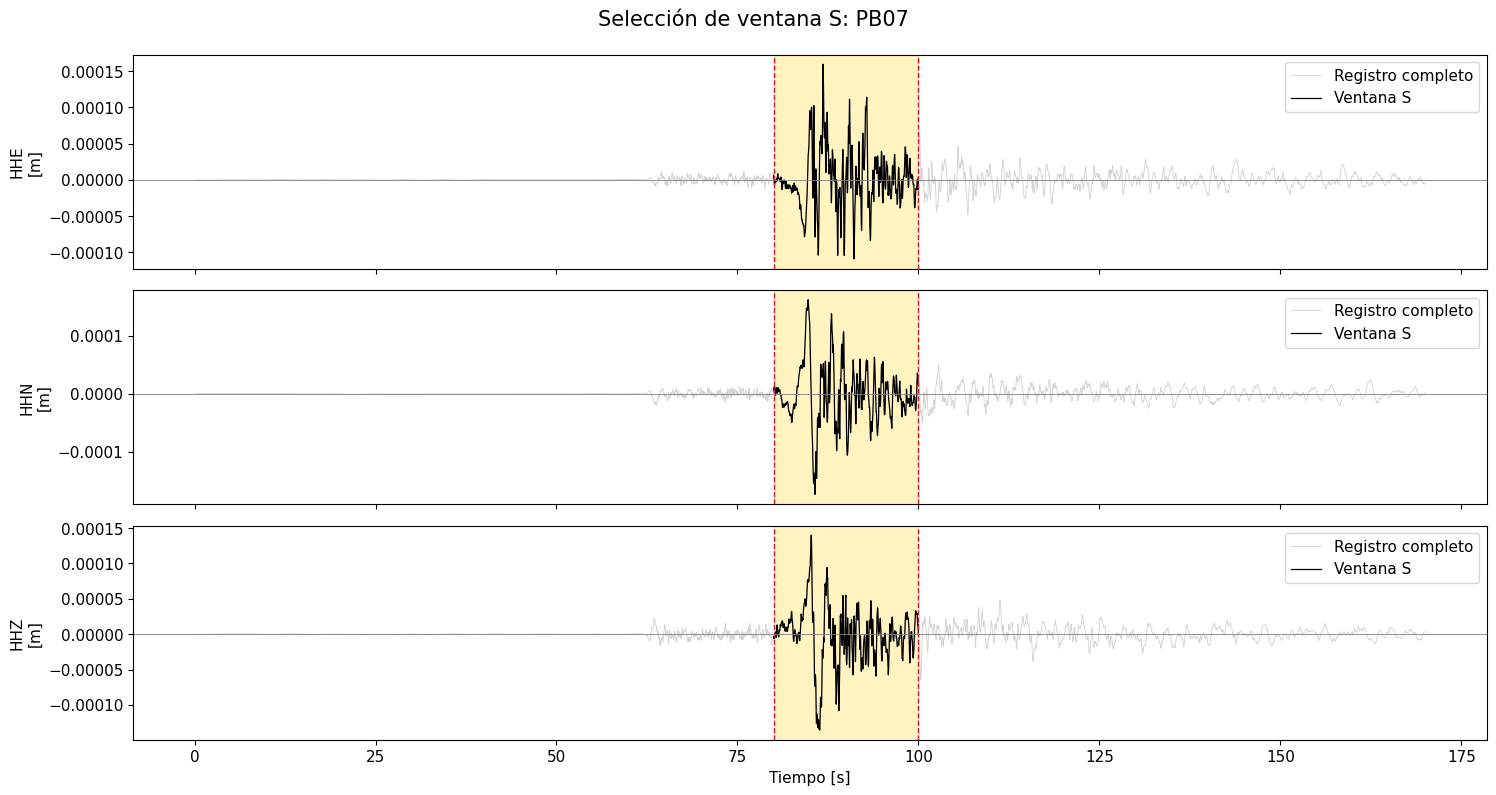

In [37]:
ESTACION_EJEMPLO = "PB07"

config = seleccion_s[ESTACION_EJEMPLO]

t_inicio_s = config["t_inicio_s"]
t_final_s = config["t_final_s"]

if t_inicio_s is None or t_final_s is None:
    raise ValueError(
        f"Define t_inicio_s y t_final_s para {ESTACION_EJEMPLO} "
        "en la celda de selección."
    )

fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 8),
    sharex=True
)

for ax, componente in zip(axes, COMPONENTES):
    clave = (ESTACION_EJEMPLO, componente)

    if clave not in trazas_int:
        ax.text(
            0.5,
            0.5,
            f"No existe la componente {componente}",
            ha="center",
            va="center"
        )
        continue

    datos = trazas_int[clave]["datos"]

    t = datos["t_s"].to_numpy()
    u = datos["desplazamiento_m"].to_numpy()

    mascara_s = (
        (t >= t_inicio_s)
        & (t <= t_final_s)
    )

    ax.plot(
        t,
        u,
        color="lightgray",
        lw=0.65,
        label="Registro completo"
    )

    ax.plot(
        t[mascara_s],
        u[mascara_s],
        color="black",
        lw=0.9,
        label="Ventana S"
    )

    ax.axvspan(
        t_inicio_s,
        t_final_s,
        color="gold",
        alpha=0.25
    )

    ax.axvline(
        t_inicio_s,
        color="crimson",
        ls="--",
        lw=1
    )

    ax.axvline(
        t_final_s,
        color="crimson",
        ls="--",
        lw=1
    )

    ax.axhline(0, color="gray", lw=0.6)

    ax.set_ylabel(f"{componente}\n[m]")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Tiempo [s]")

fig.suptitle(
    f"Selección de ventana S: {ESTACION_EJEMPLO}",
    y=0.99,
    fontsize=15
)

plt.tight_layout()
plt.savefig(
    f"/home/keneth/Documents/Academic_Projects/AGCID2026_DIS_UChile/Week3/Figures/Ventana_S_{ESTACION_EJEMPLO}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 6. Procesamiento espectral según el notebook de apoyo

Para cada componente se sigue el siguiente procedimiento, como se describe en el notebook de apoyo:

1. Extraer la ventana S seleccionada.
2. Remover media y tendencia lineal con `scipy.signal.detrend`.
3. Calcular la FFT.
4. Normalizar la FFT por el número de muestras de la ventana.
5. Convertir el resultado a un espectro unilateral de amplitud.
6. Seleccionar visualmente una región de baja frecuencia aproximadamente plana.
7. Promediar las amplitudes espectrales de esa región para obtener el plateau.

In [38]:
from scipy import signal

def extraer_ventana_s(t, u, t_inicio, t_final):
    """
    Extrae la ventana temporal de onda S.
    """
    mascara = (
        (t >= t_inicio)
        & (t <= t_final)
    )

    if mascara.sum() < 8:
        raise ValueError(
            "La ventana S contiene muy pocas muestras. "
            "Revisa los tiempos seleccionados."
        )

    return t[mascara], u[mascara]


def espectro_desplazamiento_guia(t, u):
    """
    Calcula el espectro de amplitud siguiendo la lógica de la guía:

    - Remueve tendencia lineal.
    - Calcula FFT.
    - Normaliza por el número de muestras.
    - Convierte a espectro unilateral de amplitud.

    Returns
    -------
    frecuencias : np.ndarray
        Frecuencias positivas en Hz.
    amplitud : np.ndarray
        Amplitud espectral normalizada.
    fs : float
        Frecuencia de muestreo en Hz.
    n : int
        Número de muestras en la ventana.
    """
    dt = np.median(np.diff(t))

    if dt <= 0:
        raise ValueError(
            "El vector de tiempo debe ser creciente."
        )

    fs = 1.0 / dt
    n = len(u)

    u_detrend = signal.detrend(
        u,
        type="linear"
    )

    espectro_complejo = np.fft.rfft(u_detrend) / n
    frecuencias = np.fft.rfftfreq(n, d=dt)

    amplitud = np.abs(espectro_complejo)

    # Corrección para espectro unilateral:
    # se duplica la energía de frecuencias internas,
    # pero no la frecuencia cero ni Nyquist.
    if len(amplitud) > 2:
        amplitud[1:-1] *= 2.0

    return frecuencias, amplitud, fs, n


def calcular_plateau_promedio(
    frecuencias,
    amplitud,
    fmin_hz,
    fmax_hz
):
    """
    Calcula el plateau como el promedio aritmético
    en una banda espectral seleccionada visualmente.
    """
    mascara = (
        (frecuencias >= fmin_hz)
        & (frecuencias <= fmax_hz)
    )

    if mascara.sum() < 2:
        raise ValueError(
            "La banda de plateau contiene menos de dos muestras. "
            "Amplía el rango de frecuencia o usa una ventana S más larga."
        )

    plateau = np.mean(amplitud[mascara])

    return plateau, mascara

## 7. Espectro y selección de plateau para una estación

Para esto se presentan dos paneles:

1. La señal temporal y la ventana S seleccionada.
2. Los espectros de amplitud de HHE, HHN y HHZ.

La franja gris del segundo panel corresponde a la banda de frecuencias escogida para el plateau. Cada línea discontinua representa el valor promedio de amplitud espectral calculado dentro de dicha banda.

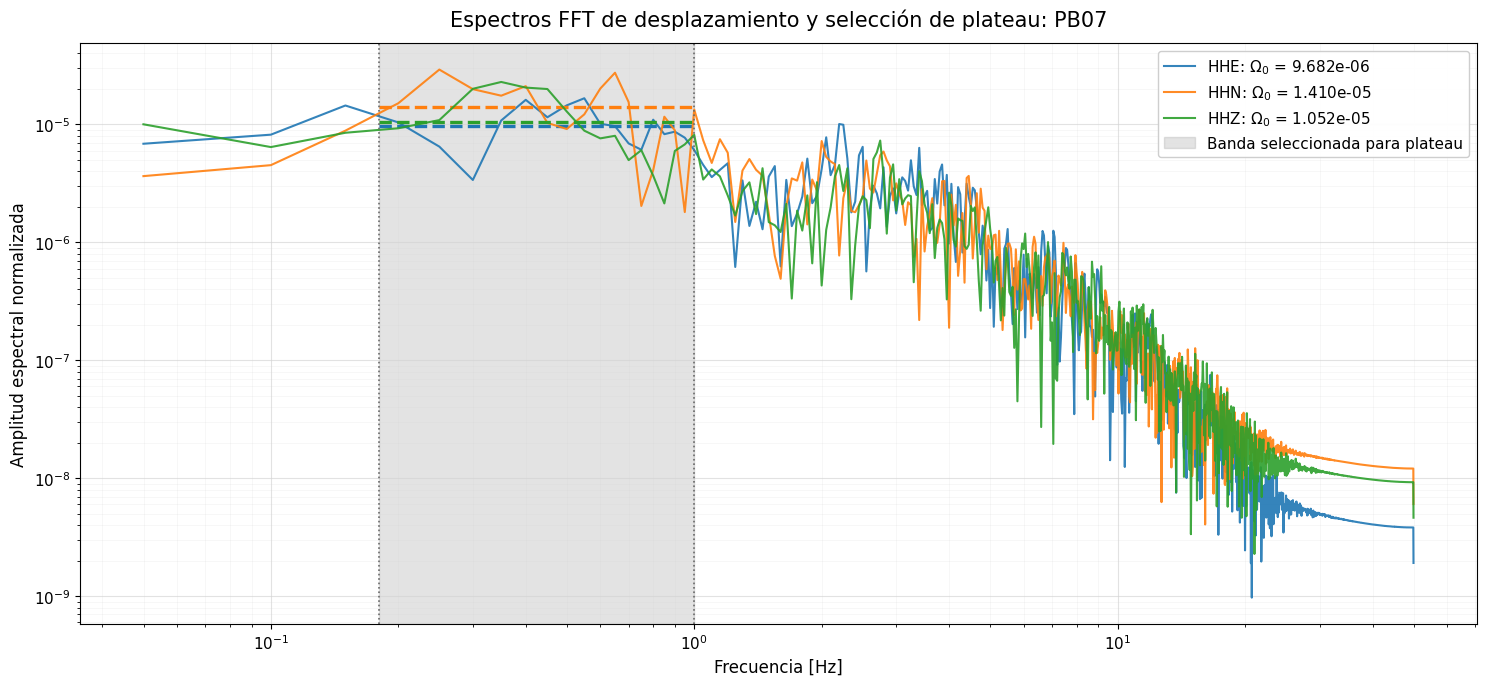

Figura guardada en:
/home/keneth/Documents/Academic_Projects/AGCID2026_DIS_UChile/Week3/Figures/FFT_plateau_PB07.png

Frecuencia de muestreo: 100.000 Hz
Muestras en la ventana S: 2001
Resolución espectral aproximada: 0.0500 Hz

Plateaus estimados:
PB07 -- HHE: Ω₀ = 9.681982e-06
PB07 -- HHN: Ω₀ = 1.409635e-05
PB07 -- HHZ: Ω₀ = 1.052245e-05


In [44]:
ESTACION_EJEMPLO = "PB07"

config = seleccion_s[ESTACION_EJEMPLO]

valores_requeridos = [
    config["t_inicio_s"],
    config["t_final_s"],
    config["fmin_plateau_hz"],
    config["fmax_plateau_hz"]
]

if any(valor is None for valor in valores_requeridos):
    raise ValueError(
        "Completa los tiempos de ventana S y la banda de plateau "
        f"para {ESTACION_EJEMPLO}."
    )

t_inicio_s = config["t_inicio_s"]
t_final_s = config["t_final_s"]
fmin_plateau = config["fmin_plateau_hz"]
fmax_plateau = config["fmax_plateau_hz"]

colores = {
    "HHE": "tab:blue",
    "HHN": "tab:orange",
    "HHZ": "tab:green"
}

plateaus_ejemplo = {}
espectros_ejemplo = {}

# Figura panorámica para visualizar plateau, frecuencia de esquina y el comienzo del decaimiento espectral.
fig, ax = plt.subplots(figsize=(15, 7))

for componente in COMPONENTES:
    clave = (ESTACION_EJEMPLO, componente)

    if clave not in trazas_int:
        print(f"No se encontró la componente: {clave}")
        continue

    datos = trazas_int[clave]["datos"]

    t = datos["t_s"].to_numpy()
    u = datos["desplazamiento_m"].to_numpy()

    # Extraer únicamente la ventana S definida previamente.
    t_s, u_s = extraer_ventana_s(
        t,
        u,
        t_inicio_s,
        t_final_s
    )

    # Calcular FFT/espectro usando la función compatible con la guía.
    f, amp, fs, n = espectro_desplazamiento_guia(
        t_s,
        u_s
    )

    # Calcular el plateau como promedio de la banda definida.
    plateau, mascara_plateau = calcular_plateau_promedio(
        f,
        amp,
        fmin_plateau,
        fmax_plateau
    )

    plateaus_ejemplo[componente] = plateau
    espectros_ejemplo[componente] = {
        "frecuencia_hz": f,
        "amplitud": amp,
        "plateau": plateau
    }

    mascara_positiva = (f > 0) & np.isfinite(amp) & (amp > 0)

    ax.loglog(
        f[mascara_positiva],
        amp[mascara_positiva],
        color=colores[componente],
        lw=1.5,
        alpha=0.90,
        label=rf"{componente}: $\Omega_0$ = {plateau:.3e}"
    )

    # Línea horizontal del plateau seleccionado.
    ax.hlines(
        plateau,
        fmin_plateau,
        fmax_plateau,
        colors=colores[componente],
        linestyles="--",
        lw=2.4
    )

# Sombreado de la banda usada para estimar el plateau.
ax.axvspan(
    fmin_plateau,
    fmax_plateau,
    color="gray",
    alpha=0.22,
    label="Banda seleccionada para plateau"
)

# Líneas verticales para visualizar los límites del intervalo.
ax.axvline(
    fmin_plateau,
    color="dimgray",
    ls=":",
    lw=1.2
)

ax.axvline(
    fmax_plateau,
    color="dimgray",
    ls=":",
    lw=1.2
)

#ax.set_xlim(0.04, 15)
#ax.set_ylim(1e-9, 1e-4)

ax.set_title(
    f"Espectros FFT de desplazamiento y selección de plateau: "
    f"{ESTACION_EJEMPLO}",
    fontsize=15,
    pad=12
)

ax.set_xlabel("Frecuencia [Hz]", fontsize=12)
ax.set_ylabel(
    "Amplitud espectral normalizada",
    fontsize=12
)

ax.grid(
    which="major",
    color="lightgray",
    alpha=0.65,
    lw=0.8
)

ax.grid(
    which="minor",
    color="lightgray",
    alpha=0.25,
    lw=0.5
)

ax.legend(
    loc="upper right",
    frameon=True,
    framealpha=0.95
)

fig.tight_layout()

ruta_salida = Path(
    "/home/keneth/Documents/Academic_Projects/"
    "AGCID2026_DIS_UChile/Week3/Figures"
)

ruta_salida.mkdir(parents=True, exist_ok=True)

archivo_salida = (
        ruta_salida
        / f"FFT_plateau_{ESTACION_EJEMPLO}.png"
)

fig.savefig(
    archivo_salida,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="white",
    transparent=False
)

plt.show()

print(f"Figura guardada en:\n{archivo_salida}")
print(f"\nFrecuencia de muestreo: {fs:.3f} Hz")
print(f"Muestras en la ventana S: {n}")
print(
    f"Resolución espectral aproximada: "
    f"{1 / (t_final_s - t_inicio_s):.4f} Hz"
)

print("\nPlateaus estimados:")
for componente, omega in plateaus_ejemplo.items():
    print(
        f"{ESTACION_EJEMPLO} -- {componente}: "
        f"Ω₀ = {omega:.6e}"
    )

## 8. Cálculo de plateaus en todas las estaciones

Una vez definidos los tiempos de ventana S y las bandas de plateau para las cinco estaciones, resta calcular:

$$
\Omega_E,\qquad
\Omega_N,\qquad
\Omega_Z.
$$

In [48]:
def validar_seleccion_s(seleccion):
    """
    Verifica que cada estación posea una ventana S y banda
    de plateau completa y válida.
    """
    errores = []

    for estacion, config in seleccion.items():
        for clave, valor in config.items():
            if valor is None:
                errores.append(
                    f"{estacion}: falta definir {clave}"
                )

        if (
            config["t_inicio_s"] is not None
            and config["t_final_s"] is not None
            and config["t_final_s"] <= config["t_inicio_s"]
        ):
            errores.append(
                f"{estacion}: t_final_s debe ser mayor que t_inicio_s"
            )

        if (
            config["fmin_plateau_hz"] is not None
            and config["fmax_plateau_hz"] is not None
            and config["fmax_plateau_hz"] <= config["fmin_plateau_hz"]
        ):
            errores.append(
                f"{estacion}: fmax_plateau_hz debe ser mayor que "
                "fmin_plateau_hz"
            )

    if errores:
        raise ValueError(
            "Configuración incompleta o inválida:\n - "
            + "\n - ".join(errores)
        )


def calcular_plateaus_todas_estaciones(trazas, seleccion):
    """
    Calcula ΩE, ΩN y ΩZ para cada estación.
    """
    validar_seleccion_s(seleccion)

    filas = []

    for estacion, config in seleccion.items():
        fila = {
            "Estación": estacion,
            "Inicio S [s]": config["t_inicio_s"],
            "Final S [s]": config["t_final_s"],
            "fmin plateau [Hz]": config["fmin_plateau_hz"],
            "fmax plateau [Hz]": config["fmax_plateau_hz"]
        }

        for componente in COMPONENTES:
            clave = (estacion, componente)

            if clave not in trazas:
                raise KeyError(
                    f"No existe la traza {clave}."
                )

            datos = trazas[clave]["datos"]

            t = datos["t_s"].to_numpy()
            u = datos["desplazamiento_m"].to_numpy()

            t_s, u_s = extraer_ventana_s(
                t,
                u,
                config["t_inicio_s"],
                config["t_final_s"]
            )

            f, amp, fs, n = espectro_desplazamiento_guia(
                t_s,
                u_s
            )

            plateau, _ = calcular_plateau_promedio(
                f,
                amp,
                config["fmin_plateau_hz"],
                config["fmax_plateau_hz"]
            )

            nombre_columna = f"Ω{componente[-1]}"

            fila[f"{nombre_columna}"] = plateau
            fila["fs [Hz]"] = fs
            fila["Muestras ventana"] = n

        filas.append(fila)

    return pd.DataFrame(filas).sort_values(
        "Estación"
    ).reset_index(drop=True)


tabla_plateaus = calcular_plateaus_todas_estaciones(
    trazas=trazas_int,
    seleccion=seleccion_s
)

tabla_plateaus_mostrar = tabla_plateaus.copy()

for columna in ["ΩE", "ΩN", "ΩZ"]:
    tabla_plateaus_mostrar[columna] = (
        tabla_plateaus_mostrar[columna]
        .map(lambda x: f"{x:.6e}")
    )

for columna in [
    "Inicio S [s]",
    "Final S [s]",
    "fmin plateau [Hz]",
    "fmax plateau [Hz]",
    "fs [Hz]"
]:
    tabla_plateaus_mostrar[columna] = (
        tabla_plateaus_mostrar[columna].round(3)
    )

print("Plateaus de las tres componentes por estación:")
tabla_plateaus_mostrar

Plateaus de las tres componentes por estación:


,Estación,Inicio S [s],Final S [s],fmin plateau [Hz],fmax plateau [Hz],ΩE,fs [Hz],Muestras ventana,ΩN,ΩZ
0,MNMCX,75.0,100.0,0.18,1.0,1.947708e-05,100.0,2501,1.228429e-05,8.030768e-06
1,PATA,70.0,90.0,0.18,3.0,1.671666e-05,100.0,2001,1.201279e-05,9.276532e-06
2,PB07,80.0,100.0,0.18,1.0,9.681982e-06,100.0,2001,1.409635e-05,1.052245e-05
3,PSGCX,70.0,90.0,0.18,0.8,1.866120e-05,100.0,2001,1.088838e-05,7.574153e-06
4,UNAP,70.0,85.0,0.22,1.0,2.909854e-05,100.0,1501,2.245424e-05,1.630629e-05


## 9. Cálculo de momento sísmico y magnitud de momento

Para cada estación se combinan los plateaus de las tres componentes:

$$
\Omega_{\mathrm{RMS}} =
\left(
\frac{
\Omega_E^2+\Omega_N^2+\Omega_Z^2
}{3}
\right)^{1/2}.
$$

Luego se calcula:

$$
M_0 =
4\pi\rho\beta^3R
\frac{V}{\left< R_S \right>}
\Omega_{\mathrm{RMS}}.
$$

Finalmente:

$$
M_w =
\frac{2}{3}
\log_{10}(M_0)
-6.07.
$$

Las conversiones a unidades SI se aplican internamente:

- $\rho$: de $\mathrm{g/cm^3}$ a $\mathrm{kg/m^3}$;
- $\beta$: de $\mathrm{km/s}$ a $\mathrm{m/s}$;
- $R$: de km a m.

El momento sísmico final queda expresado en $\mathrm{N\,m}$.

In [49]:
def calcular_momento_y_mw(
    omega_E,
    omega_N,
    omega_Z,
    delta_km,
    profundidad_km=PROFUNDIDAD_KM,
    rho_g_cm3=DENSIDAD_G_CM3,
    beta_km_s=VELOCIDAD_S_KM_S,
    V=FACTOR_SUPERFICIE_LIBRE,
    R_s=PATRON_RADIACION_PROMEDIO
):
    """
    Calcula R, ΩRMS, M0 y Mw por estación.
    """
    rho_kg_m3 = rho_g_cm3 * 1000.0
    beta_m_s = beta_km_s * 1000.0

    R_km = calcular_distancia_hipocentral(
        delta_km,
        profundidad_km
    )

    R_m = R_km * 1000.0

    omega_rms = np.sqrt(
        (
            omega_E**2
            + omega_N**2
            + omega_Z**2
        ) / 3.0
    )

    M0_Nm = (
        4.0
        * np.pi
        * rho_kg_m3
        * beta_m_s**3
        * R_m
        * V
        * omega_rms
        / R_s
    )

    Mw = (
        (2.0 / 3.0)
        * np.log10(M0_Nm)
        - 6.07
    )

    return {
        "R hipocentral [km]": R_km,
        "ΩRMS": omega_rms,
        "M0 [N m]": M0_Nm,
        "Mw estación": Mw
    }


filas_resultados_mw = []

for _, fila in tabla_plateaus.iterrows():
    estacion = fila["Estación"]

    resultado = calcular_momento_y_mw(
        omega_E=fila["ΩE"],
        omega_N=fila["ΩN"],
        omega_Z=fila["ΩZ"],
        delta_km=DISTANCIAS_EPICENTRALES_KM[estacion]
    )

    filas_resultados_mw.append({
        "Estación": estacion,
        "Δ epicentral [km]": DISTANCIAS_EPICENTRALES_KM[estacion],
        "R hipocentral [km]": resultado["R hipocentral [km]"],
        "ΩE": fila["ΩE"],
        "ΩN": fila["ΩN"],
        "ΩZ": fila["ΩZ"],
        "ΩRMS": resultado["ΩRMS"],
        "M0 [N m]": resultado["M0 [N m]"],
        "Mw estación": resultado["Mw estación"]
    })

tabla_mw_estaciones = pd.DataFrame(
    filas_resultados_mw
).sort_values(
    "Estación"
).reset_index(drop=True)

tabla_mw_mostrar = tabla_mw_estaciones.copy()

for columna in ["ΩE", "ΩN", "ΩZ", "ΩRMS", "M0 [N m]"]:
    tabla_mw_mostrar[columna] = (
        tabla_mw_mostrar[columna]
        .map(lambda x: f"{x:.6e}")
    )

for columna in [
    "Δ epicentral [km]",
    "R hipocentral [km]"
]:
    tabla_mw_mostrar[columna] = (
        tabla_mw_mostrar[columna].round(2)
    )

tabla_mw_mostrar["Mw estación"] = (
    tabla_mw_mostrar["Mw estación"].round(3)
)

print("Resultados de momento sísmico y Mw por estación:")
display(tabla_mw_mostrar)

Resultados de momento sísmico y Mw por estación:


,Estación,Δ epicentral [km],R hipocentral [km],ΩE,ΩN,ΩZ,ΩRMS,M0 [N m],Mw estación
0,MNMCX,113.7,145.01,1.947708e-05,1.228429e-05,8.030768e-06,1.408017e-05,2.827283e+16,4.898
1,PATA,93.0,129.42,1.671666e-05,1.201279e-05,9.276532e-06,1.303595e-05,2.336159e+16,4.842
2,PB07,185.9,206.54,9.681982e-06,1.409635e-05,1.052245e-05,1.159267e-05,3.315532e+16,4.944
3,PSGCX,100.7,135.06,1.866120e-05,1.088838e-05,7.574153e-06,1.321824e-05,2.472050e+16,4.859
4,UNAP,84.8,123.66,2.909854e-05,2.245424e-05,1.630629e-05,2.321503e-05,3.975148e+16,4.996


## 10. Magnitud de momento final y error estadístico

La magnitud final se obtiene promediando las estimaciones de las estaciones:

$$
\overline{M_w}
=
\frac{1}{N}
\sum_{i=1}^{N}M_{w,i}.
$$

Se reportan dos medidas de dispersión:

- La desviación estándar entre estaciones.
- El error estándar de la media:

$$
\mathrm{SEM} =
\frac{s}{\sqrt{N}}.
$$

El resultado final puede reportarse entonces como:

$$
M_w =
\overline{M_w}
\pm
\mathrm{SEM}.
$$

Resumen estadístico final:


,Número de estaciones,Mw promedio final,Mediana de Mw,Desviación estándar entre estaciones,Error estándar de la media
0,5,4.908,4.898,0.063,0.028


Resultado recomendado:
Mw = 4.91 ± 0.03 (error estándar; N = 5)
Desviación estándar entre estaciones: σ = 0.06


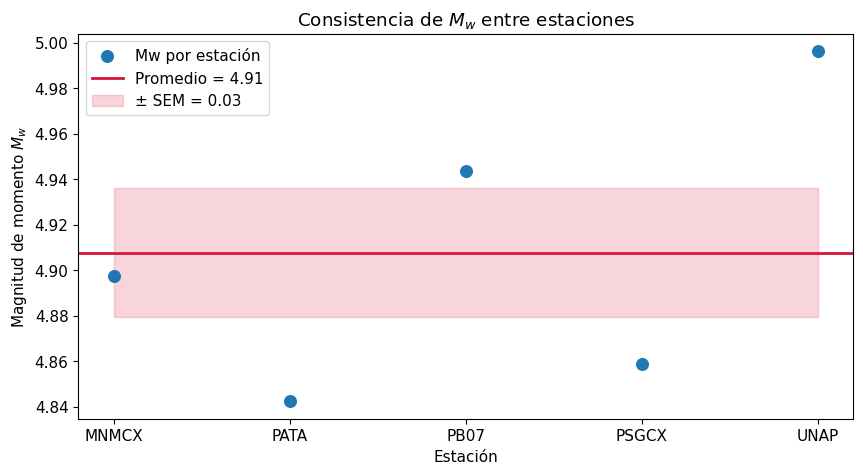

In [50]:
mw_por_estacion = (
    tabla_mw_estaciones["Mw estación"]
    .dropna()
    .to_numpy()
)

n_estaciones = len(mw_por_estacion)

Mw_final = np.mean(mw_por_estacion)

desviacion_estandar_mw = (
    np.std(mw_por_estacion, ddof=1)
    if n_estaciones > 1
    else np.nan
)

error_estandar_mw = (
    desviacion_estandar_mw / np.sqrt(n_estaciones)
    if n_estaciones > 1
    else np.nan
)

mediana_mw = np.median(mw_por_estacion)

resumen_final_mw = pd.DataFrame([
    {
        "Número de estaciones": n_estaciones,
        "Mw promedio final": Mw_final,
        "Mediana de Mw": mediana_mw,
        "Desviación estándar entre estaciones": (
            desviacion_estandar_mw
        ),
        "Error estándar de la media": error_estandar_mw
    }
])

resumen_final_mw_mostrar = resumen_final_mw.copy()

for columna in [
    "Mw promedio final",
    "Mediana de Mw",
    "Desviación estándar entre estaciones",
    "Error estándar de la media"
]:
    resumen_final_mw_mostrar[columna] = (
        resumen_final_mw_mostrar[columna].round(3)
    )

print("Resumen estadístico final:")
display(resumen_final_mw_mostrar)

print(
    f"Resultado recomendado:\n"
    f"Mw = {Mw_final:.2f} ± {error_estandar_mw:.2f} "
    f"(error estándar; N = {n_estaciones})"
)

print(
    f"Desviación estándar entre estaciones: "
    f"σ = {desviacion_estandar_mw:.2f}"
)

x = np.arange(n_estaciones)

plt.figure(figsize=(10, 5))

plt.scatter(
    x,
    tabla_mw_estaciones["Mw estación"],
    color="tab:blue",
    s=70,
    zorder=3,
    label="Mw por estación"
)

plt.axhline(
    Mw_final,
    color="crimson",
    lw=2,
    label=f"Promedio = {Mw_final:.2f}"
)

plt.fill_between(
    x,
    Mw_final - error_estandar_mw,
    Mw_final + error_estandar_mw,
    color="crimson",
    alpha=0.18,
    label=f"± SEM = {error_estandar_mw:.2f}"
)

plt.xticks(
    x,
    tabla_mw_estaciones["Estación"]
)

plt.xlabel("Estación")
plt.ylabel("Magnitud de momento $M_w$")
plt.title("Consistencia de $M_w$ entre estaciones")
plt.legend()
plt.show()

In [51]:
from pathlib import Path
import subprocess
import sys

NOTEBOOK = Path("Calculo_Mw.ipynb")

if not NOTEBOOK.exists():
    raise FileNotFoundError(
        f"No se encontró el notebook:\n{NOTEBOOK.resolve()}\n\n"
        "Guarda primero el notebook y actualiza la variable NOTEBOOK "
        "con su nombre o ruta correcta."
    )

comando = [
    sys.executable,
    "-m",
    "jupyter",
    "nbconvert",
    "--to",
    "pdf",
    "--PDFExporter.exclude_input=False",
    str(NOTEBOOK)
]

try:
    resultado = subprocess.run(
        comando,
        check=True,
        text=True,
        capture_output=True
    )

    pdf = NOTEBOOK.with_suffix(".pdf")

    print(resultado.stdout)

    if pdf.exists():
        print(f"PDF creado correctamente:\n{pdf.resolve()}")
    else:
        print(
            "El comando terminó sin error, pero no se encontró el PDF "
            "en la ubicación esperada."
        )

except subprocess.CalledProcessError as error:
    print("No fue posible exportar el notebook a PDF.\n")
    print("Salida estándar:")
    print(error.stdout)
    print("\nMensajes de error:")
    print(error.stderr)


PDF creado correctamente:
/home/keneth/Documents/Academic_Projects/AGCID2026_DIS_UChile/Week3/Calculo_Mw.pdf
